In [1]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as ss
import seaborn as sns

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# set figure parameters
sc.settings.set_figure_params(dpi=100)

In [2]:
from celcomen.models.celcomen import celcomen
from celcomen.models.simcomen import simcomen

## define helper functions

In [3]:
# define a function to normalize the g2g
def normalize_g2g(g2g):
    """
    Addresses any small fluctuations in symmetrical weights
    """
    # symmetrize the values
    g2g = (g2g + g2g.T) / 2
    # force them to be between 0-1
    g2g[g2g < 0] = 0
    g2g[g2g > 1] = 1
    # force the central line to be 1
    for idx in range(len(g2g)):
        g2g[idx, idx] = 1
    return g2g

## read in xenium

In [4]:
# read in xenium
avis = sc.read_10x_h5('data/xenium_human_gbm/cell_feature_matrix.h5')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# remove cells with no counts
sc.pp.filter_cells(avis, min_counts=100)
# normalize the data
sc.pp.normalize_total(avis, target_sum=1e6)
sc.pp.log1p(avis)

In [5]:
# read in the spatial
df = pd.read_csv('data/xenium_human_gbm/cells.csv.gz', index_col=0)
df = df.loc[avis.obs.index]

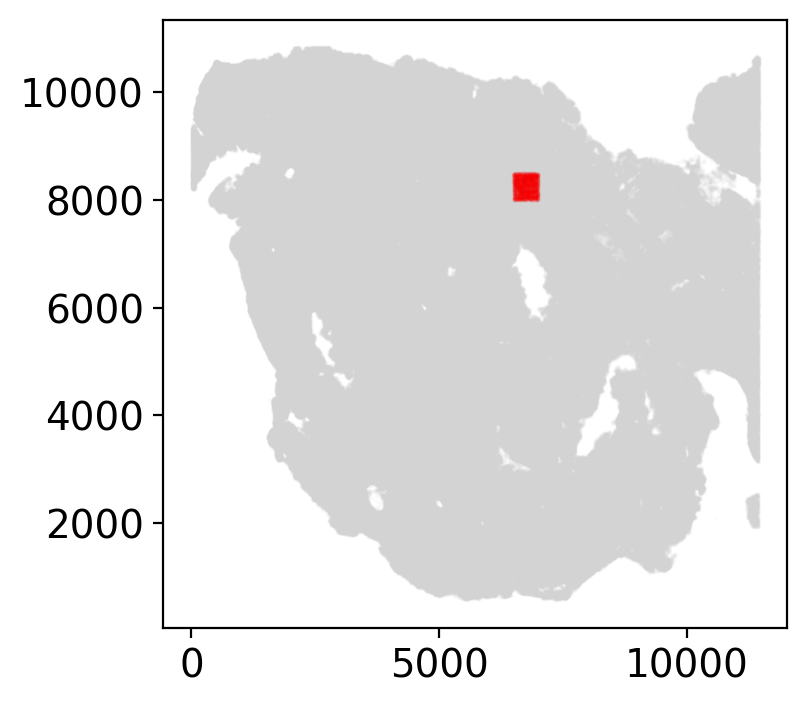

In [6]:
# view the tissue and choose a specific area to focus on
fig, ax = plt.subplots()
ax.grid(False)
ax.scatter(df['x_centroid'], df['y_centroid'], s=0.1, alpha=0.1, color='lightgray')
mask = (df['x_centroid'] < 7000) & (df['x_centroid'] > 6500)
mask = mask & (df['y_centroid'] < 8500) & (df['y_centroid'] > 8000)
ax.scatter(df.loc[mask, 'x_centroid'], df.loc[mask, 'y_centroid'], s=0.1, alpha=0.1, color='r')

In [7]:
# add spatial and subset
avis.obsm['spatial'] = df.loc[avis.obs.index, ['x_centroid','y_centroid']].values
avis = avis[mask].copy()

/nfs/team205/sm58/packages/celcomen_trials/pyg_env/celcomen_tutorial_env/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:251: UserWarning: If you pass `n_top_genes`, all cutoffs are ignored.
  warnings.warn(msg, UserWarning)
/nfs/team205/sm58/packages/celcomen_trials/pyg_env/celcomen_tutorial_env/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:412: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)


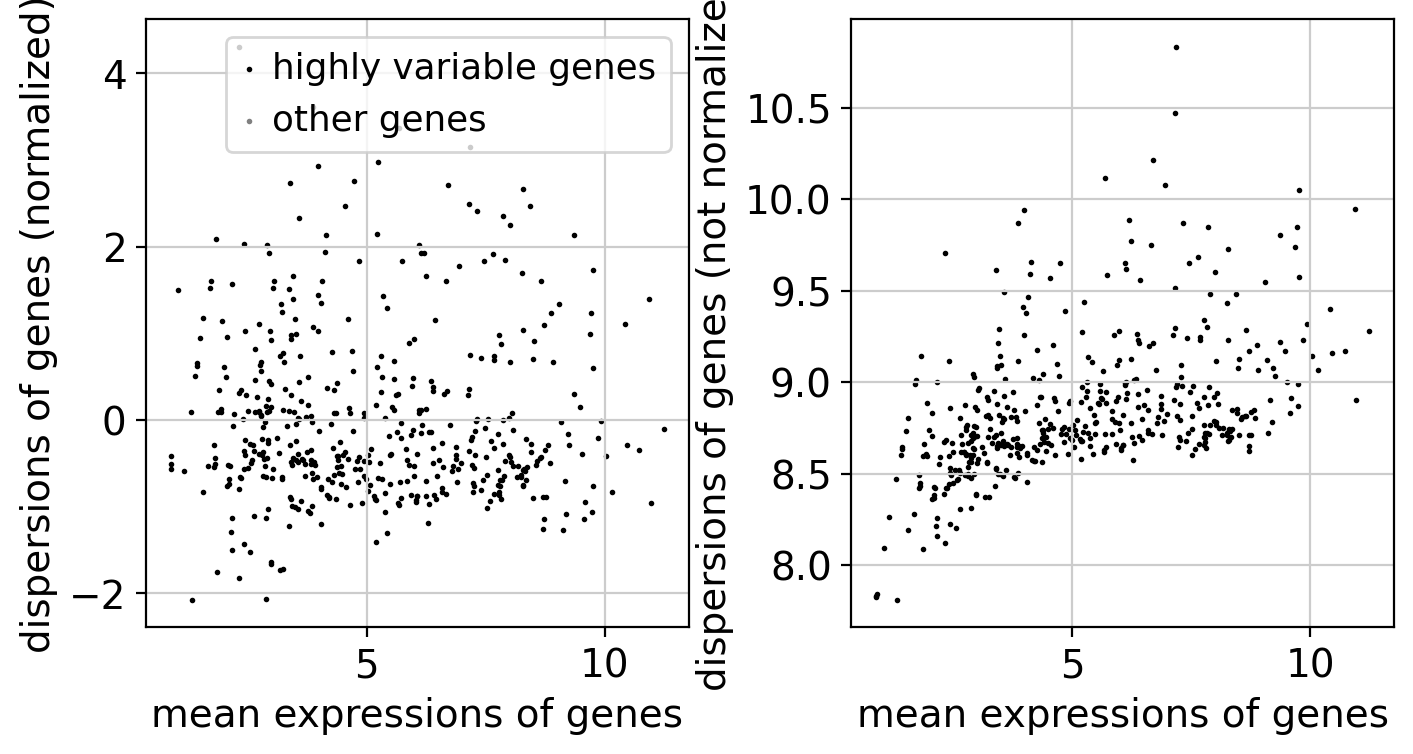

there are 480 hvgs


In [8]:
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, flavor='seurat', min_mean=0.5, max_mean=7.5, min_disp=0.5, n_top_genes=avis.shape[1])
sc.pl.highly_variable_genes(avis)
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')

In [9]:
# the dataloader of celcomen takes as input the raw counts which it then log-transforms and normalizes
# so we need to reread the anndata from raw, and subset to the genes we computed based on the log-counts in avis

genes = avis.var_names[avis.var['highly_variable']].tolist()

avis2 = sc.read_10x_h5('data/xenium_human_gbm/cell_feature_matrix.h5')
avis2.var_names = avis.var_names.astype(str)
avis2.var_names_make_unique()
# remove cells with no counts
sc.pp.filter_cells(avis2, min_counts=100)
# insert spatial coordinates
avis2.obsm['spatial'] = df.loc[avis2.obs.index, ['x_centroid','y_centroid']].values

avis3 = avis2[mask, genes].copy()
# put a sample id
sc.pp.filter_genes(avis3, min_cells=5)
avis3.obs["sangerID"] = "sample1"

avis3.write_h5ad(
    'data/xenium_human_gbm/avis_for_data_loading.h5',
)

## learn with CCE for xenium

In [10]:
import torch
torch.cuda.is_available()

True

In [11]:
from scipy.spatial.distance import pdist, squareform

distances = squareform(pdist(df.loc[mask, ['x_centroid','y_centroid']]))
# compute the edges as two cell widths apart so 30µm
edge_index = torch.from_numpy(np.array(np.where((distances < 15)&(distances != 0))))

In [12]:
from celcomen.training_plan.train import train
from celcomen.datareaders.datareader import get_dataset_loaders

In [13]:
genes = avis3.var.index

In [14]:
h5ad_path='data/xenium_human_gbm/avis_for_data_loading.h5'

loader = get_dataset_loaders(h5ad_path, "sangerID", 6, True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[1781, 412], edge_index=[2, 10686], y=[1], pos=[1781, 2], batch=[1781], ptr=[2])



In [15]:
n_genes= len(genes) #33
n_neighbors=6
seed=1
zmft_scalar = 0.1
epochs = 300
learning_rate = 5e-3


model = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
model.to("cuda")
losses = train(epochs, learning_rate, model, loader, zmft_scalar=zmft_scalar, seed=1, device="cuda")


100%|███████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:05<00:00, 54.26it/s]


[Text(0.5, 0, 'epochs'), Text(0, 0.5, 'loss')]

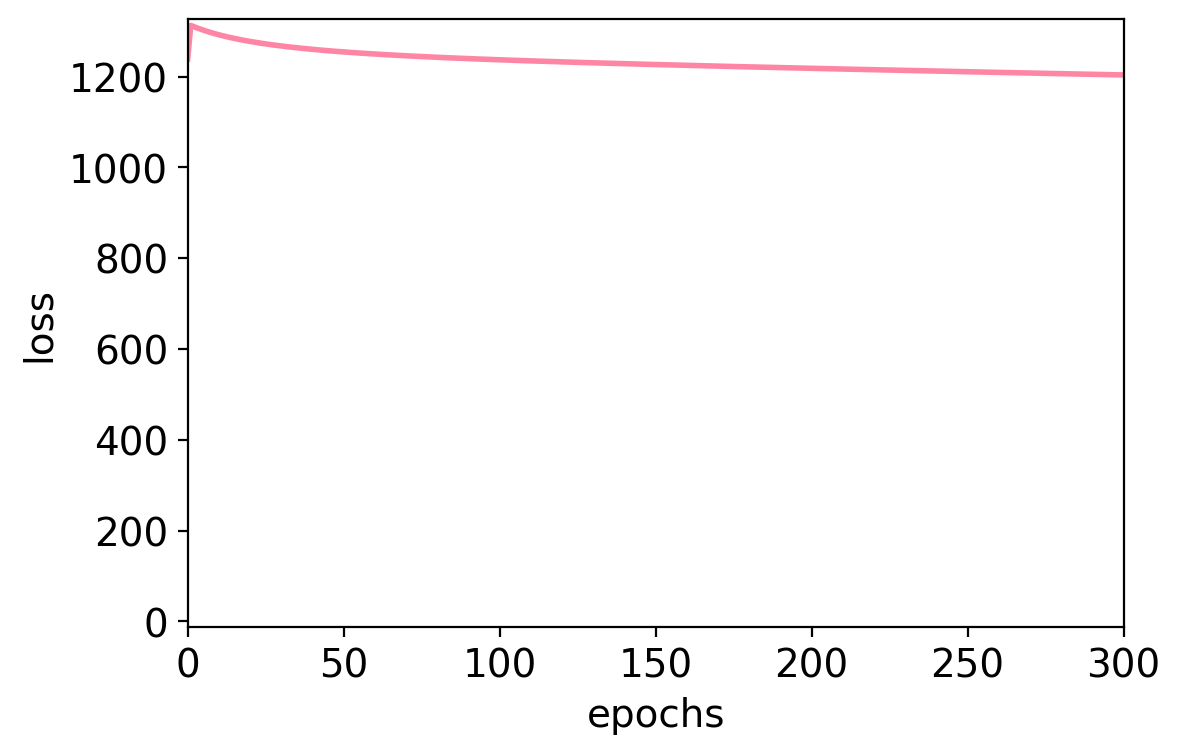

In [16]:
# create the plot
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs)
vmin, vmax = min(min(losses), 0), max(losses)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='epochs', ylabel='loss')

## perform disentanglement

In [17]:
# retrieve the g2gs
g2g_intercellular = pd.DataFrame(model.conv1.lin.weight.detach().cpu().numpy(), index=genes, columns=genes)
g2g_intracellular = pd.DataFrame(model.lin.weight.detach().cpu().numpy(), index=genes, columns=genes)

In [18]:
# define the gene
secs = pd.read_table('data/quickgo_secreted.tsv')['SYMBOL'].unique()
sps = pd.read_table('data/quickgo_surfaceprotein.tsv')['SYMBOL'].unique()
nons = pd.Index(genes)[(~pd.Index(genes).isin(secs))&(~pd.Index(genes).isin(sps))]
secs = pd.Index(genes).intersection(secs)
sps = pd.Index(genes).intersection(sps)

/tmp/ipykernel_3660406/755115305.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/tmp/ipykernel_3660406/755115305.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/tmp/ipykernel_3660406/755115305.py:13: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/tmp/ipykernel_3660406/755115305.py:13: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.b

0.7916493459738212
6.602549668308228e-05
0.00011133531698984277


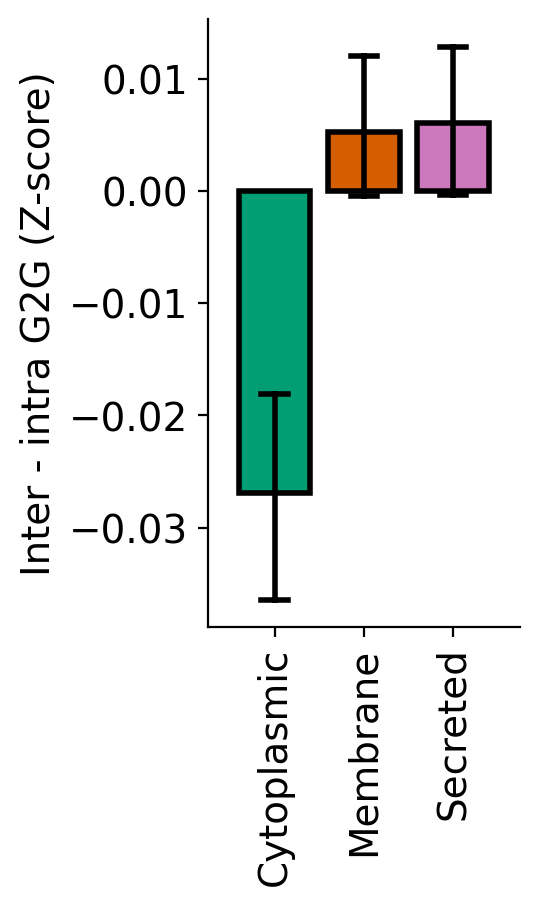

In [19]:
# derive the values
diffs_secs = (g2g_intercellular.loc[secs, :] - g2g_intracellular.loc[secs, :]).values.flatten()
diffs_sps = (g2g_intercellular.loc[sps, :] - g2g_intracellular.loc[sps, :]).values.flatten()
diffs_nons = (g2g_intercellular.loc[nons, :] - g2g_intracellular.loc[nons, :]).values.flatten()
# assemble them
ys = np.hstack([diffs_secs, diffs_sps, diffs_nons])
ys -= ys.mean()
ys /= ys.std()
xs = np.array(['Secreted']*len(diffs_secs)+['Membrane']*len(diffs_sps)+['Cytoplasmic']*len(diffs_nons))
# create plot
fig, ax = plt.subplots(figsize=[2, 4])
ax.grid(False)
sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
            errcolor='k', edgecolor='k', palette=['#cc78bc','#d55e00','#029e73'][::-1])
ax.set_xlim(-0.75, 2.75)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Inter - intra G2G (Z-score)')
ax.spines[['right', 'top']].set_visible(False)
# derive pvalues
p1 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Membrane'])[1]
p2 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Cytoplasmic'])[1]
p3 = ss.mannwhitneyu(ys[xs == 'Cytoplasmic'], ys[xs == 'Membrane'])[1]
print(p1, p2, p3, sep='\n')

## perturb the GBM data

In [20]:
# define a function to derive the gex from the sphex
def calc_sphex(gex):
    """
    Calculates the spherical expression matrix from the normal
    """
    # setup the gex
    n_sgenes = gex.shape[1]-1
    sphex = torch.from_numpy(np.zeros((gex.shape[0], n_sgenes)).astype('float32'))
    # compute the gex
    for idx in range(n_sgenes):
        sphex[:,idx] = gex[:,idx]
        for idx_ in range(idx):
            sphex[:,idx] /= torch.sin(sphex[:,idx_])
        sphex[:,idx] = torch.arccos(sphex[:,idx])
    return sphex

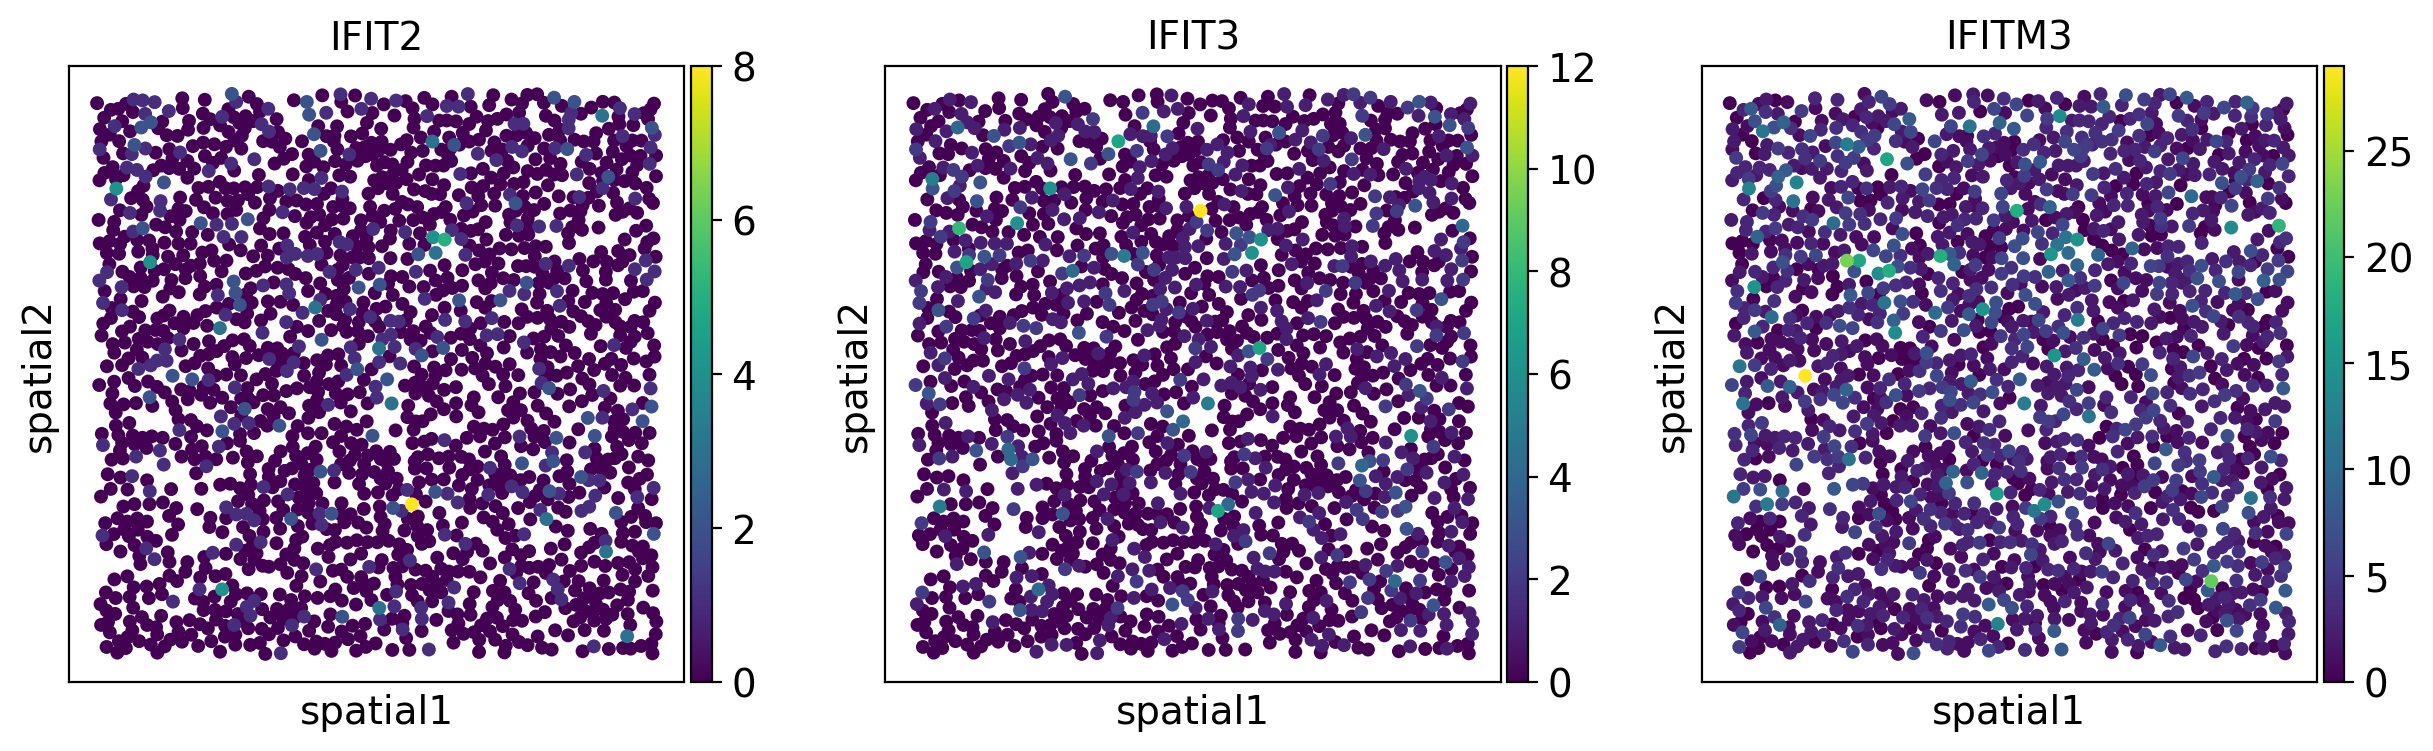

In [21]:
# find the genes
# avis_sub = avis[:, avis.var['highly_variable']].copy()
avis_sub = avis3.copy()
sc.pl.embedding(avis_sub, basis='spatial', color=['IFIT2','IFIT3','IFITM3'], use_raw=False, s=1e2)

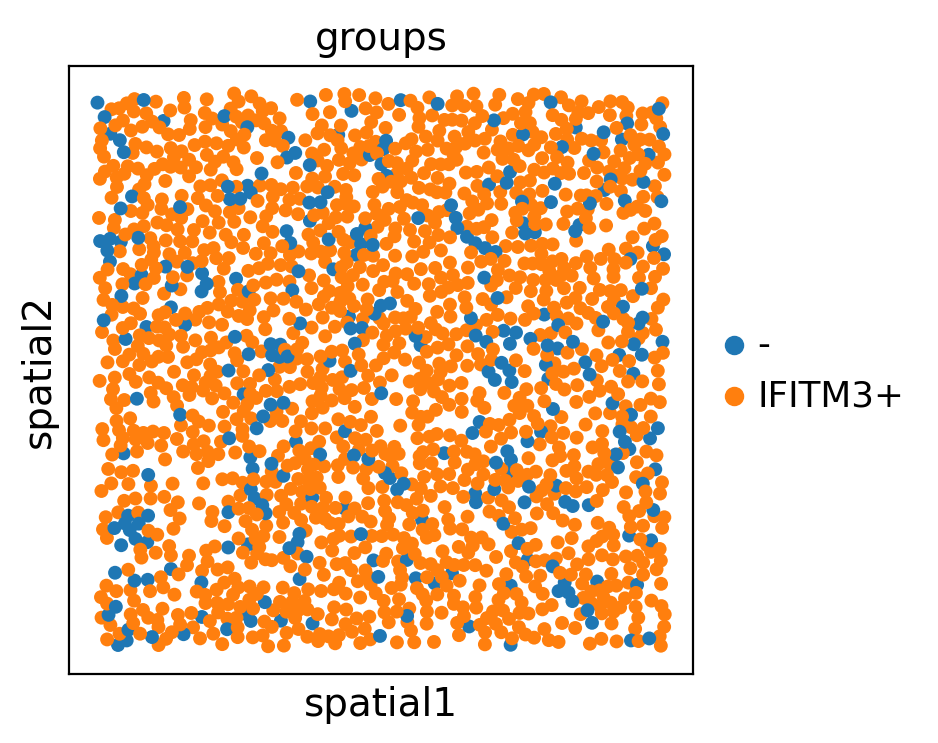

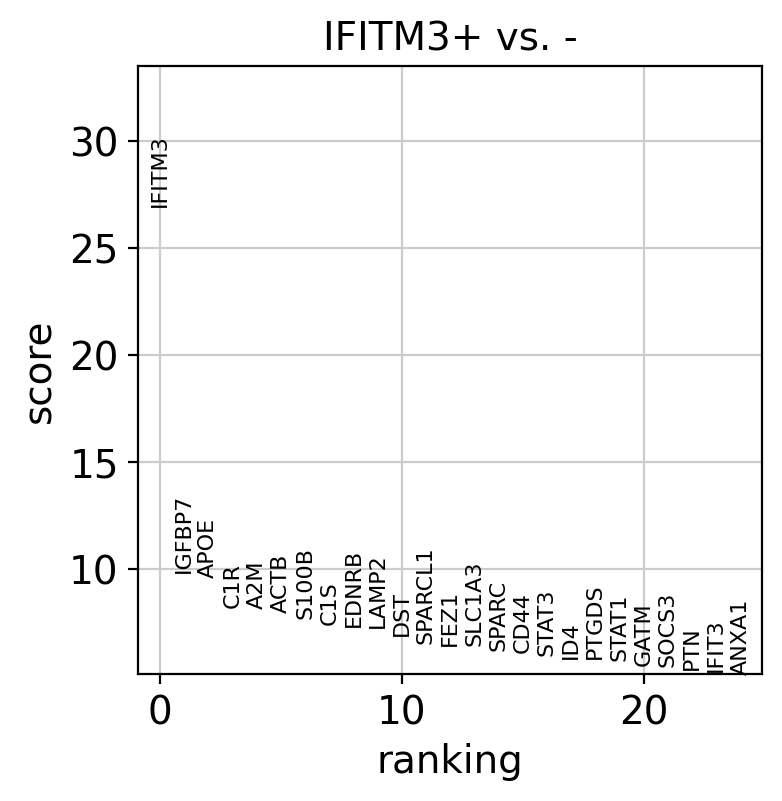

In [22]:
# define the genes that distinguish ISG15 spots currently
avis_sub.obs['groups'] = (sc.get.obs_df(avis_sub, keys=['IFITM3']).max(1) > 0).map({True:'IFITM3+', False:'-'})
sc.pl.embedding(avis_sub, basis='spatial', color=['groups'], use_raw=False, s=1e2)
# calculate differential expression
sc.tl.rank_genes_groups(avis_sub, method='wilcoxon', use_raw=False, groupby='groups', group=['IFITM3+'], reference='-')
sc.pl.rank_genes_groups(avis_sub, n_genes=25, sharey=False)

In [23]:
# derive the signature
'\''+'\',\''.join(pd.DataFrame(avis_sub.uns['rank_genes_groups']['names']).iloc[:25, 0].tolist())+'\''

"'IFITM3','IGFBP7','APOE','C1R','A2M','ACTB','S100B','C1S','EDNRB','LAMP2','DST','SPARCL1','FEZ1','SLC1A3','SPARC','CD44','STAT3','ID4','PTGDS','STAT1','GATM','SOCS3','PTN','IFIT3','ANXA1'"

In [24]:
from scipy.spatial.distance import pdist, squareform

/tmp/ipykernel_3660406/1489802821.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  avis_sub.obs['perturbed'].iloc[np.where(squareform(pdist(avis_sub.obsm['spatial']))[mask, :] < 30)[1]] = 'perturbed-neighbors1'
/tmp/ipykernel_3660406/148

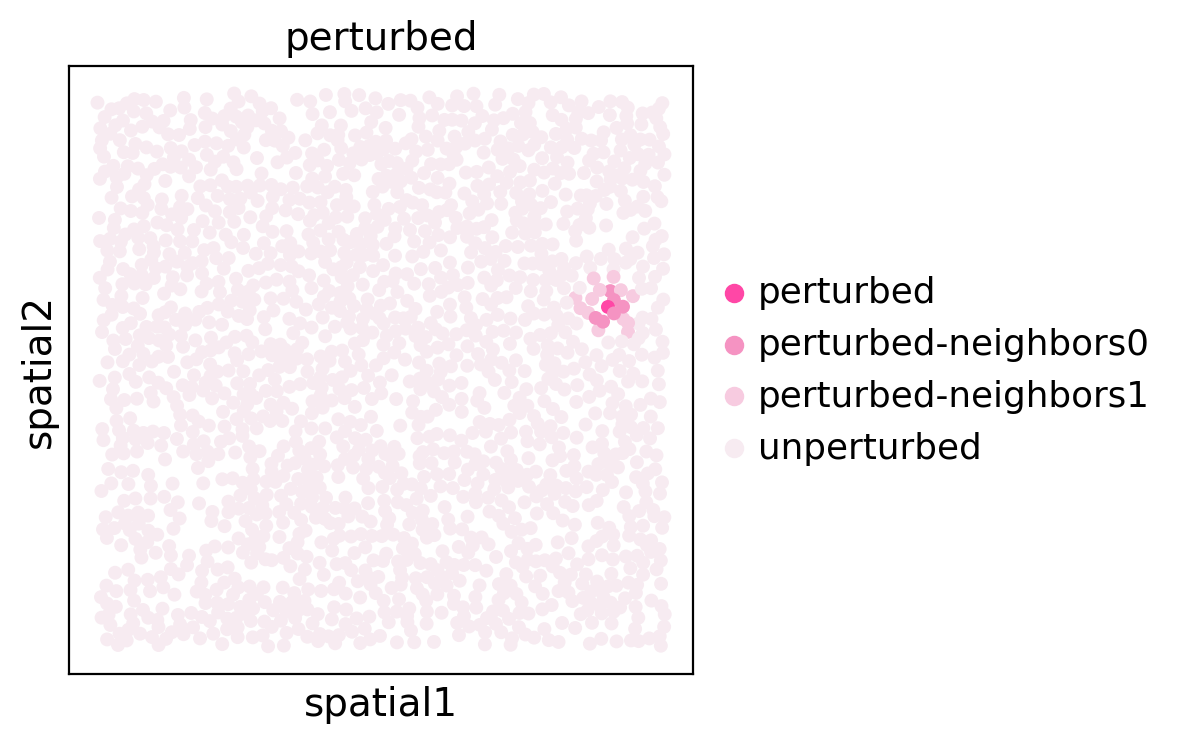

In [25]:
# propose an X introducing ISG15 inflammation
proposed_x = avis_sub.X.toarray().copy()
# adjust the X so we artificially introduce signaling to the center left side of the tissue
np.random.seed(0)
df_gex = sc.get.obs_df(avis_sub, keys=['IFITM3'])['IFITM3']
mask = avis_sub.obs.index == np.random.choice(avis_sub.obs.index[df_gex > 0], size=1)[0]
idx = np.where(avis_sub.var_names == 'IFITM3')[0][0]
proposed_x[mask, idx] = 0
avis_sub.obs['perturbed'] = 'unperturbed'
avis_sub.obs['perturbed'].iloc[np.where(squareform(pdist(avis_sub.obsm['spatial']))[mask, :] < 30)[1]] = 'perturbed-neighbors1'
avis_sub.obs['perturbed'].iloc[np.where(squareform(pdist(avis_sub.obsm['spatial']))[mask, :] < 15)[1]] = 'perturbed-neighbors0'
avis_sub.obs.loc[mask, 'perturbed'] = 'perturbed'
avis_sub.uns['perturbed_colors'] = ['#ff47a6','#f593c2','#f7cbe0','#f7ebf1']
sc.pl.embedding(avis_sub, basis='spatial', color=['perturbed'], use_raw=False, s=1e2)

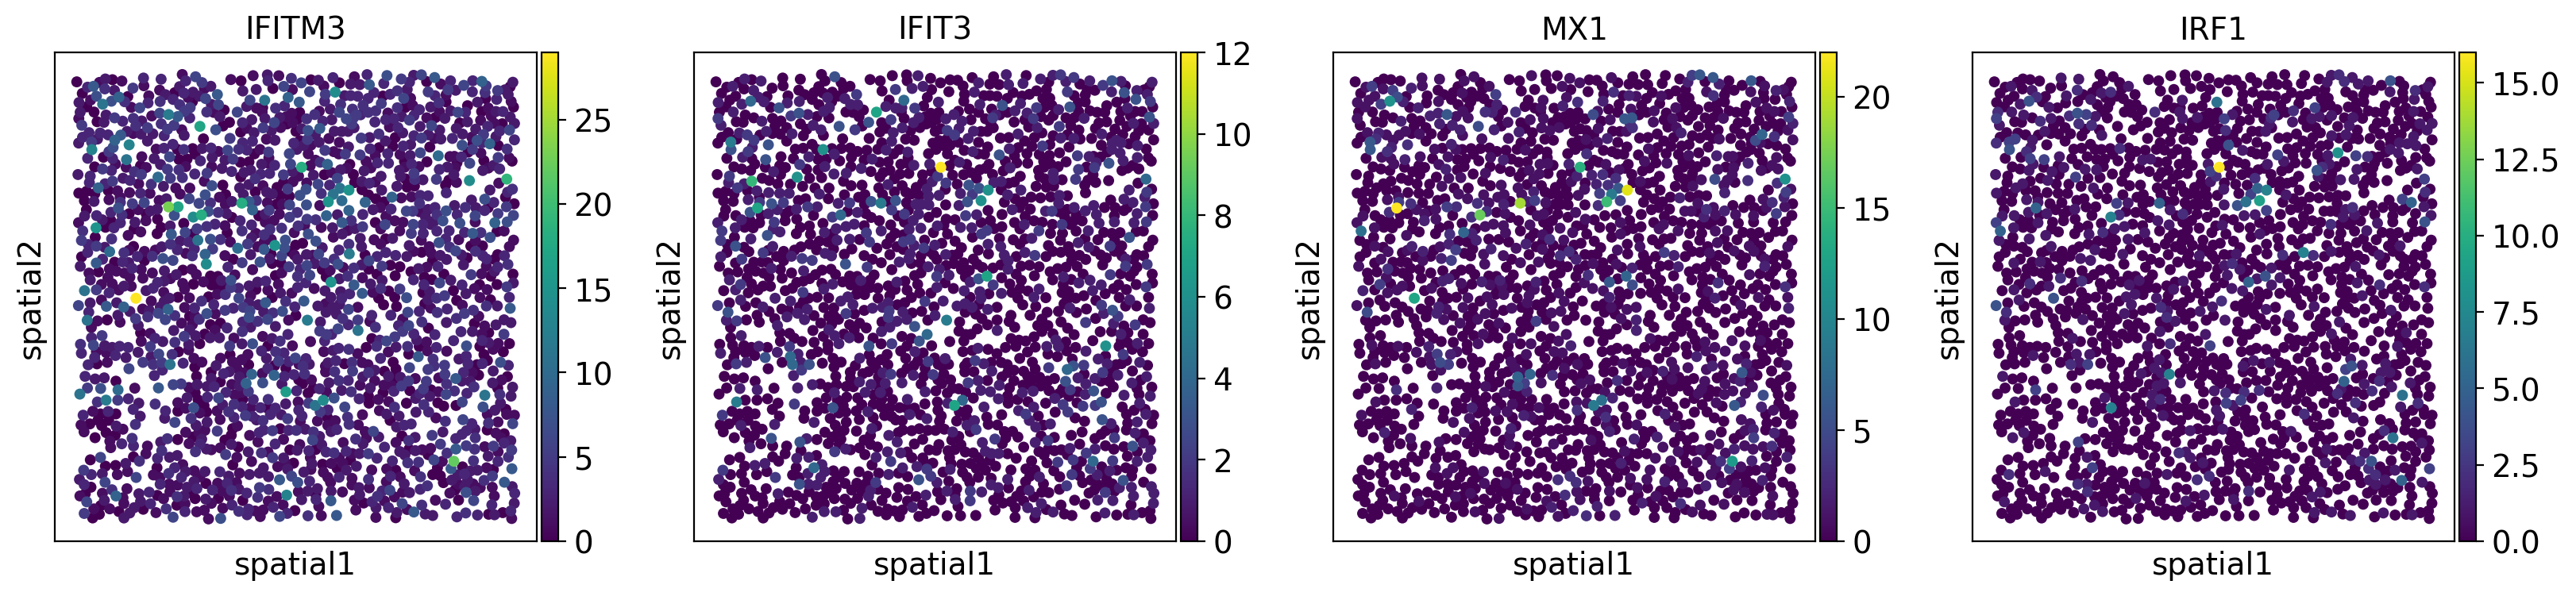

In [26]:
# demonstrate what the proposed x looks like pre scaling
import scipy.sparse
avis_sub.X = scipy.sparse.csr_matrix(proposed_x)
sc.pl.embedding(avis_sub, basis='spatial', color=['IFITM3','IFIT3','MX1','IRF1'], use_raw=False, s=1e2)

## Run Simcomen

In [27]:
# define the parameters of the model
n_genes = avis_sub.shape[1]
learning_rate = 1e-3
zmft_scalar = 1e-1
seed = 0
epochs = 50

In [28]:
# instantiate the model, input and output will be the same
model_gen = simcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# now perform the simulation
np.random.seed(seed)
# convert the gene expression data to numpy
x = torch.from_numpy(proposed_x)
# sphere normalize the data (just in case)
norm_factor = torch.sqrt(torch.pow(x, 2).sum(1)).reshape(-1,1)
assert (norm_factor > 0).all()
x = torch.div(x, norm_factor)
# artifically set the g2g matrix
model_gen.set_g2g(model.conv1.lin.weight.clone().detach())
model_gen.set_g2g_intra(model.lin.weight.clone().detach())
# initialize a gene expression matrix
input_sphex = calc_sphex(x).clone().detach().numpy()


In [29]:
next(model_gen.parameters()).device

device(type='cpu')

In [30]:
# move tensors and model to device cuda
device="cuda"
model_gen.to("cuda")
model_gen.set_sphex( torch.from_numpy(input_sphex.astype('float32')).to("cuda")  )

In [31]:
from tqdm import tqdm
# set up the optimizer
optimizer = torch.optim.SGD(model_gen.parameters(), lr=learning_rate, momentum=0)
# keep track of the losses per data object
loss, losses = None, []
# train the model
model_gen.train()
tmp_gexs = []
# work through epochs
for epoch in tqdm(range(epochs), total=epochs):
    # derive the message as well as the mean field approximation
    msg, msg_intra, log_z_mft = model_gen(edge_index.to('cuda'), 1)
    if (epoch % 5) == 0:
        if device=="cpu":
            tmp_gex = model.gex.clone().detach().numpy()
        else:
            tmp_gex = model.gex.clone().detach().cpu().numpy()
        tmp_gexs.append(tmp_gex)
# compute the loss and track it
    loss = -(-log_z_mft + zmft_scalar * torch.trace(torch.mm(msg, torch.t(model_gen.gex))) + zmft_scalar * torch.trace(torch.mm(msg_intra, torch.t(model_gen.gex))) )
    if device=="cpu":
        losses.append(loss.detach().numpy()[0][0])
    else:
        losses.append(loss.detach().cpu().numpy()[0][0])    
    print(f"Loss={losses[-1]}")
    # derive the gradients, update, and clear
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  0%|                                                                                                      | 0/50 [00:00<?, ?it/s]

self.gex device is cuda:0
edge_index device is cuda:0
Loss=3479.942626953125


  2%|█▉                                                                                            | 1/50 [00:13<11:23, 13.95s/it]

self.gex device is cuda:0
edge_index device is cuda:0
Loss=1494.6629638671875


  4%|███▊                                                                                          | 2/50 [00:28<11:23, 14.23s/it]

...

 96%|█████████████████████████████████████████████████████████████████████████████████████████▎   | 48/50 [12:10<00:30, 15.02s/it]

self.gex device is cuda:0
edge_index device is cuda:0
Loss=1463.308349609375


 98%|███████████████████████████████████████████████████████████████████████████████████████████▏ | 49/50 [12:25<00:14, 14.95s/it]

self.gex device is cuda:0
edge_index device is cuda:0
Loss=1463.067138671875


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [12:40<00:00, 15.21s/it]


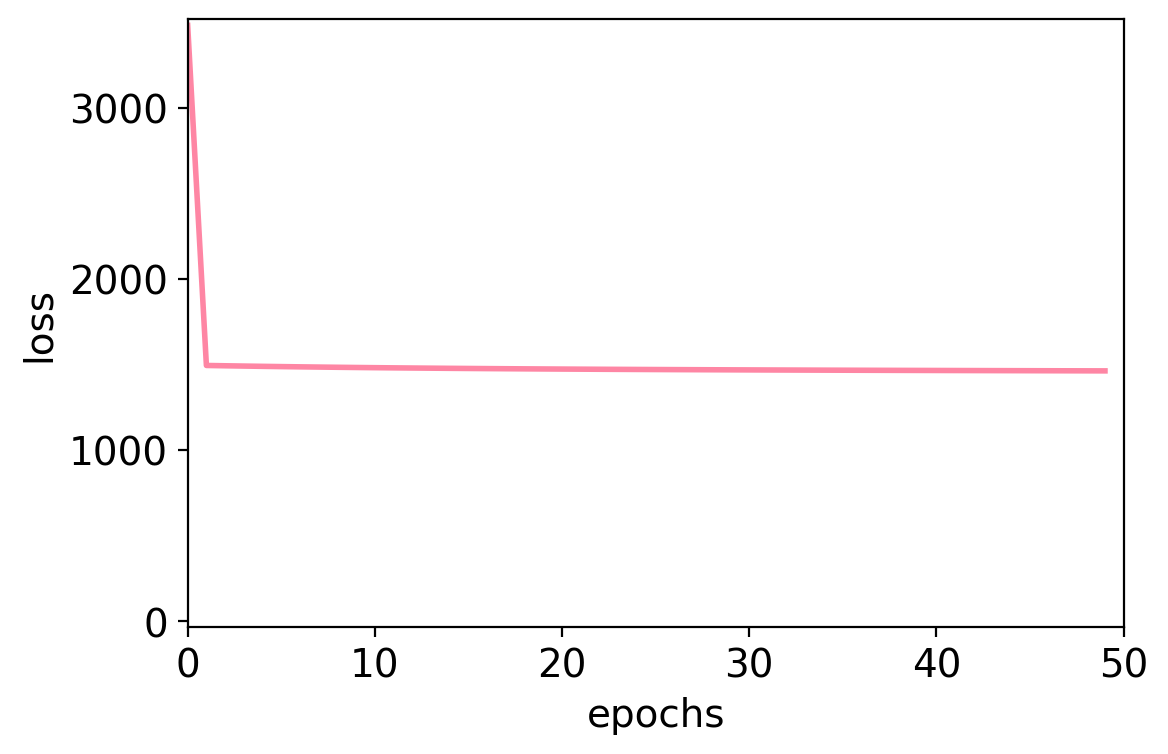

In [32]:
# plot the loss
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs)
vmin, vmax = min(min(losses), 0), max(losses)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='epochs', ylabel='loss')
# retrieve the data
if device=="cpu":
    output_gex = model_gen.gex.detach().numpy()
    output_msg = msg.detach().numpy()
else:
    output_gex = model_gen.gex.detach().cpu().numpy()
    output_msg = msg.detach().cpu().numpy()

In [33]:
# find the genes of interest
genes = ['IFITM3','IFIT3','MX1','IRF1']
genes = [x for x in genes if x in avis_sub.var_names.tolist()]

In [34]:
# add the layers
for idx, tmp_gex in enumerate(tmp_gexs):
    avis_sub.layers[f'input{idx}'] = tmp_gex
avis_sub.layers['output'] = output_gex

In [35]:
avis_sub

AnnData object with n_obs × n_vars = 1781 × 412
    obs: 'n_counts', 'sangerID', 'groups', 'perturbed'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'groups_colors', 'rank_genes_groups', 'perturbed_colors'
    obsm: 'spatial'
    layers: 'input0', 'input1', 'input2', 'input3', 'input4', 'input5', 'input6', 'input7', 'input8', 'input9', 'output'

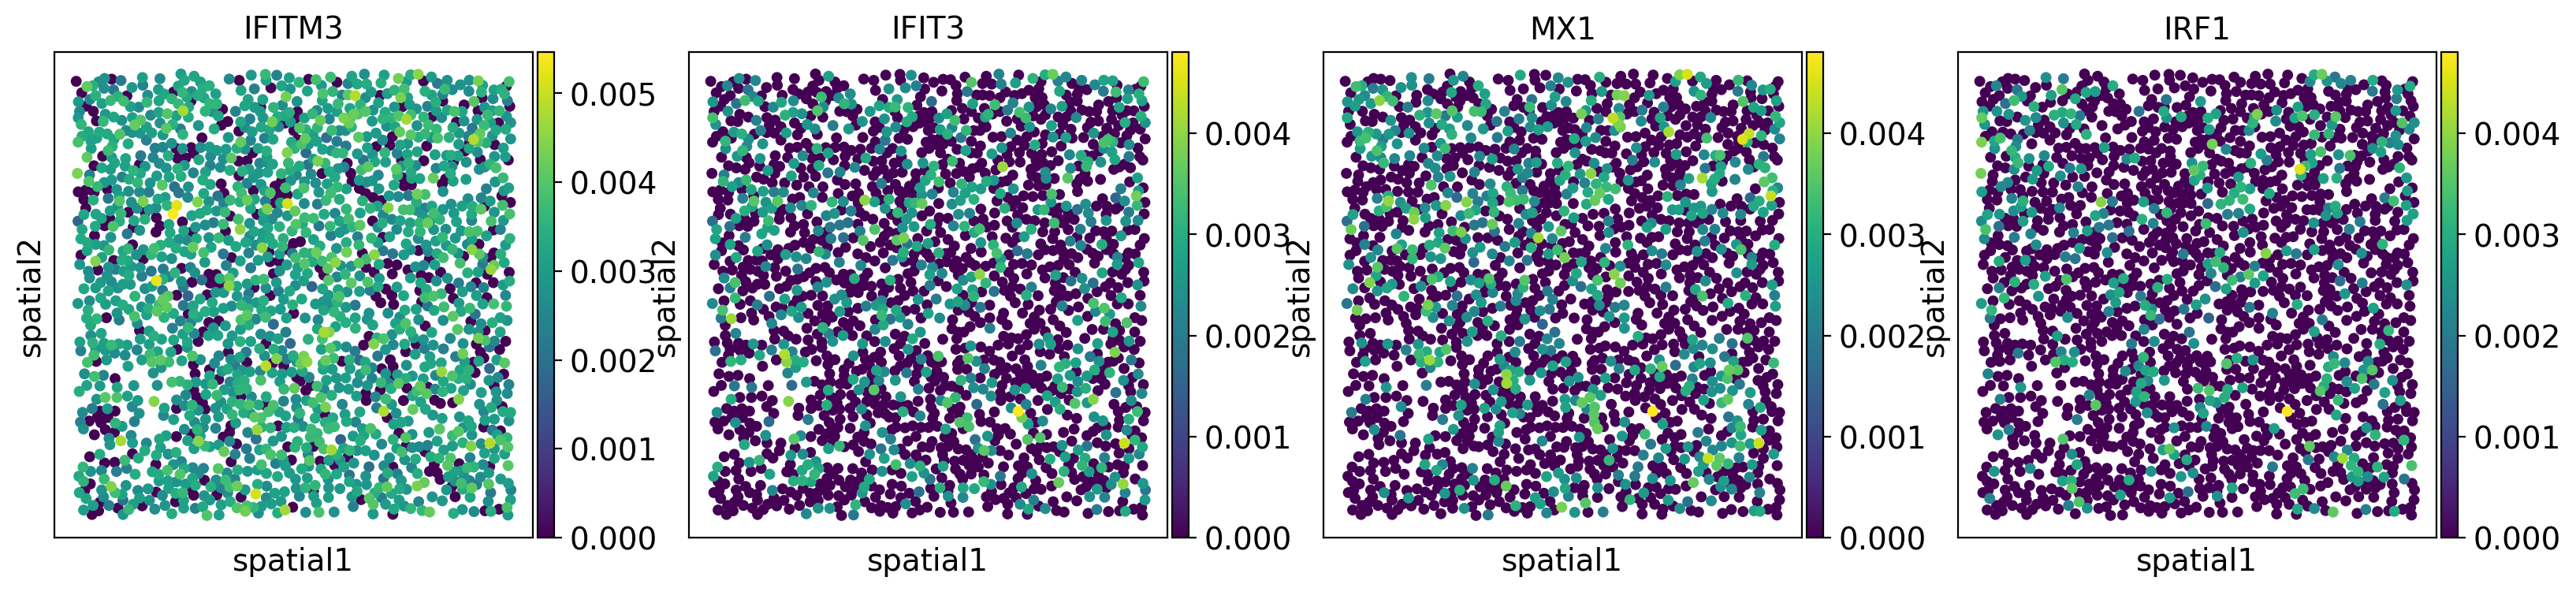

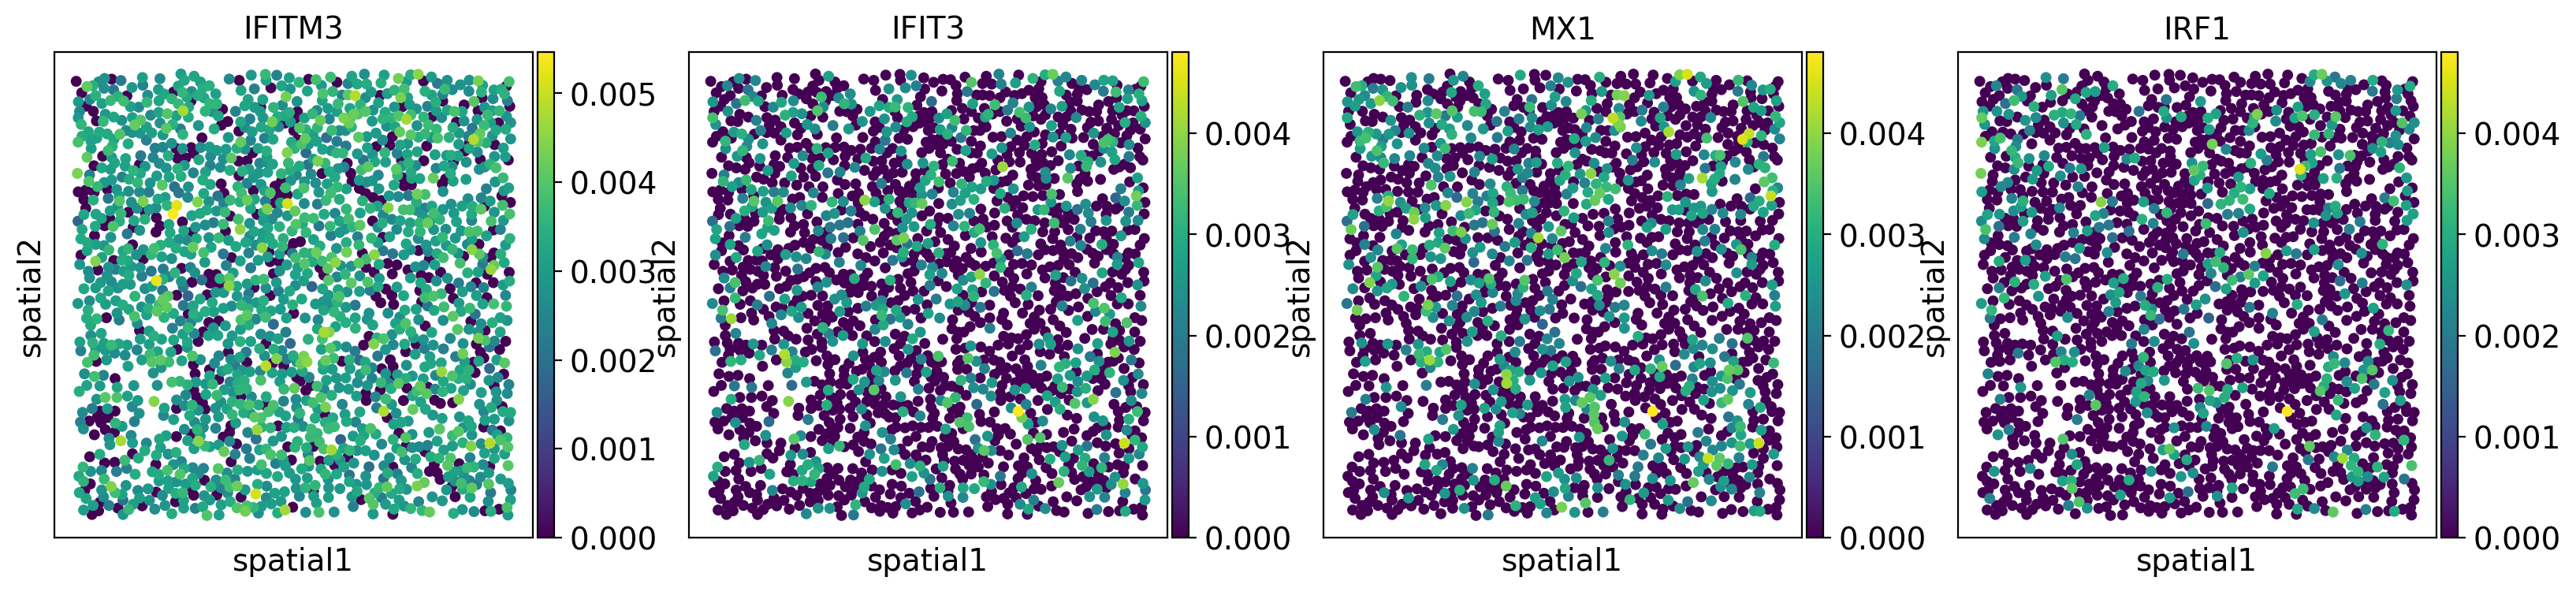

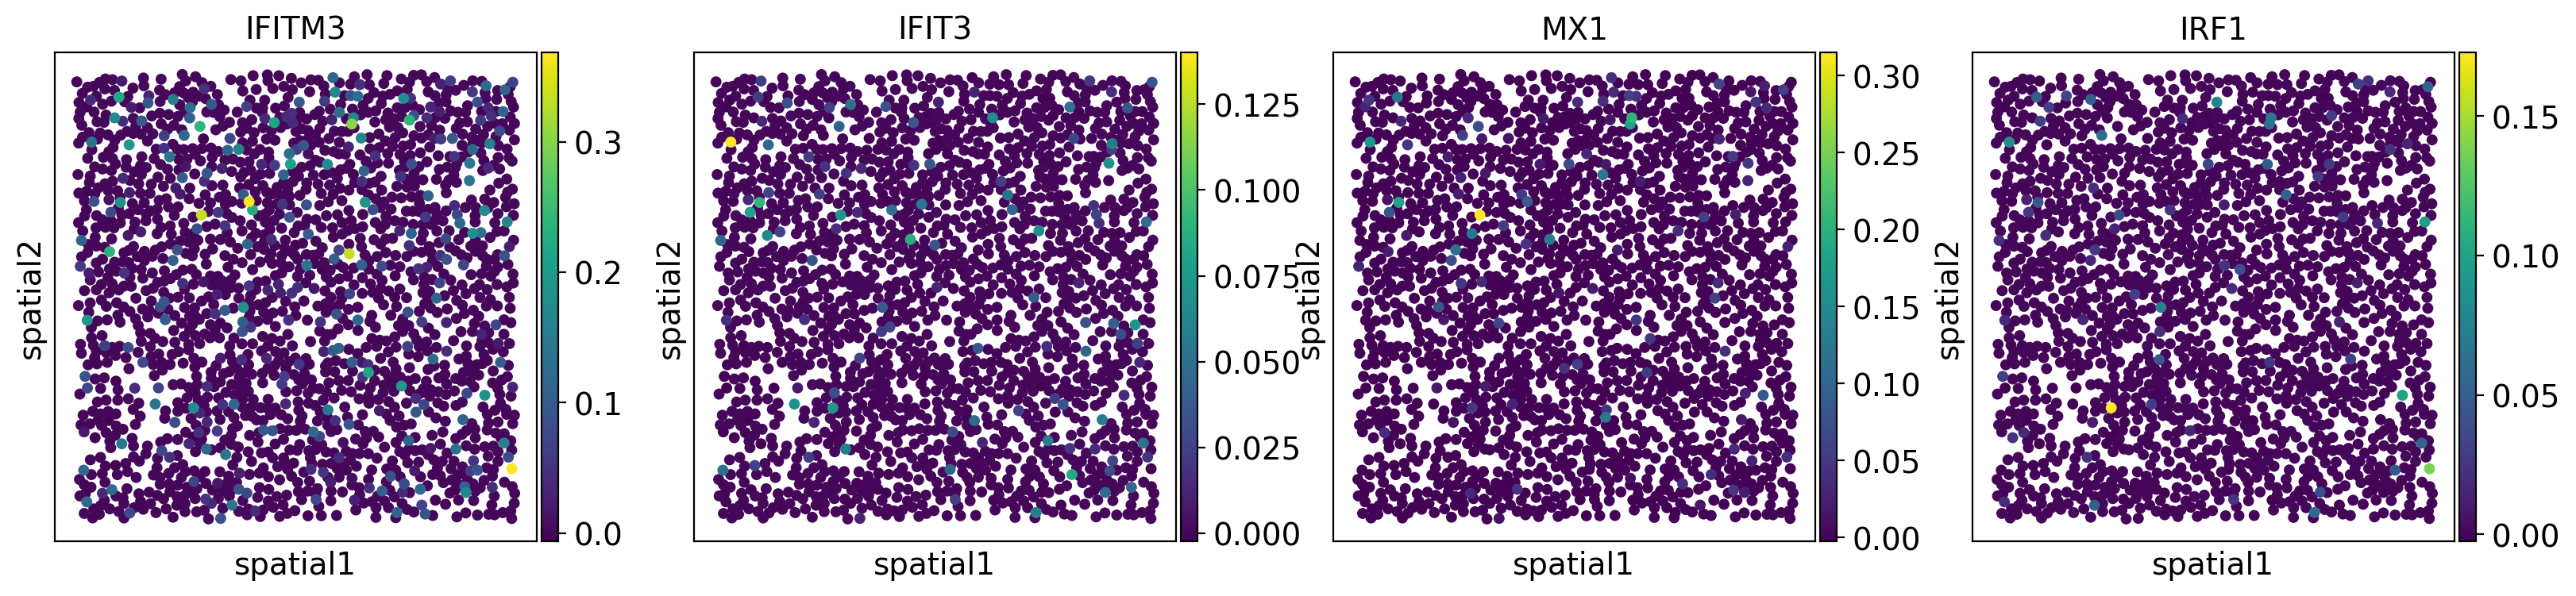

In [36]:
# plot the genes of interest
sc.pl.embedding(avis_sub, basis='spatial', color=genes, use_raw=False, s=1e2, layer='input0')
sc.pl.embedding(avis_sub, basis='spatial', color=genes, use_raw=False, s=1e2, layer='input3')
sc.pl.embedding(avis_sub, basis='spatial', color=genes, use_raw=False, s=1e2, layer='output')

In [37]:
# compute the differential within the area of interest vs outside
avis_sub.layers['diff'] = avis_sub.layers['output'] - avis_sub.layers['input0']
mask0 = avis_sub.obs['perturbed'] == 'unperturbed'
mask1 = avis_sub.obs['perturbed'] == 'perturbed'
diff_in_vs_out_p = pd.Series((avis_sub.layers['diff'][mask1].mean(0) - avis_sub.layers['diff'][mask0].mean(0)),
                             index=avis_sub.var_names).sort_values()[::-1]
# now compute differential for neighbors
mask1 = avis_sub.obs['perturbed'] == 'perturbed-neighbors0'
diff_in_vs_out_pn0 = pd.Series((avis_sub.layers['diff'][mask1].mean(0) - avis_sub.layers['diff'][mask0].mean(0)),
                             index=avis_sub.var_names).sort_values()[::-1]
mask1 = avis_sub.obs['perturbed'] == 'perturbed-neighbors1'
diff_in_vs_out_pn1 = pd.Series((avis_sub.layers['diff'][mask1].mean(0) - avis_sub.layers['diff'][mask0].mean(0)),
                             index=avis_sub.var_names).sort_values()[::-1]
# remove the perturbed genes to get a clean look
perturbed_genes = ['IFITM3']
perturbed_label = 'ifitm3'
diff_in_vs_out_p = diff_in_vs_out_p.loc[~diff_in_vs_out_p.index.isin(perturbed_genes)]
diff_in_vs_out_pn0 = diff_in_vs_out_pn0.loc[~diff_in_vs_out_pn0.index.isin(perturbed_genes)]
diff_in_vs_out_pn1 = diff_in_vs_out_pn1.loc[~diff_in_vs_out_pn1.index.isin(perturbed_genes)]
# write these matrices out
diff_in_vs_out_p.to_csv(f'20240618.learn_then_perturb.xenium_gbm.{perturbed_label}.diff_in_vs_out_p.csv')
diff_in_vs_out_pn0.to_csv(f'20240618.learn_then_perturb.xenium_gbm.{perturbed_label}.diff_in_vs_out_pn0.csv')
diff_in_vs_out_pn1.to_csv(f'20240618.learn_then_perturb.xenium_gbm.{perturbed_label}.diff_in_vs_out_pn1.csv')

In [38]:
# do not include isg15 itself
genes_ = pd.DataFrame(avis_sub.uns['rank_genes_groups']['names']).iloc[:25, 0].tolist()[1:]

In [39]:
# retrieve the results
df_expr = pd.DataFrame(columns=['p','pn0','pn1','u'])
for layer in ['input1','input2','input3','input4','input5','input6','input7','input8','input9','output']:
    # compute the expression
    mask1 = avis_sub.obs['perturbed'] == 'perturbed'
    expr_p = pd.Series(avis_sub.layers[layer][mask1].mean(0), index=avis_sub.var_names).loc[genes_].mean()
    mask1 = avis_sub.obs['perturbed'] == 'perturbed-neighbors0'
    expr_pn0 = pd.Series(avis_sub.layers[layer][mask1].mean(0), index=avis_sub.var_names).loc[genes_].mean()
    mask1 = avis_sub.obs['perturbed'] == 'perturbed-neighbors1'
    expr_pn1 = pd.Series(avis_sub.layers[layer][mask1].mean(0), index=avis_sub.var_names).loc[genes_].mean()
    mask1 = avis_sub.obs['perturbed'] == 'unperturbed'
    expr_u = pd.Series(avis_sub.layers[layer][mask1].mean(0), index=avis_sub.var_names).loc[genes_].mean()
    df_expr.loc[layer] = expr_p, expr_pn0, expr_pn1, expr_u

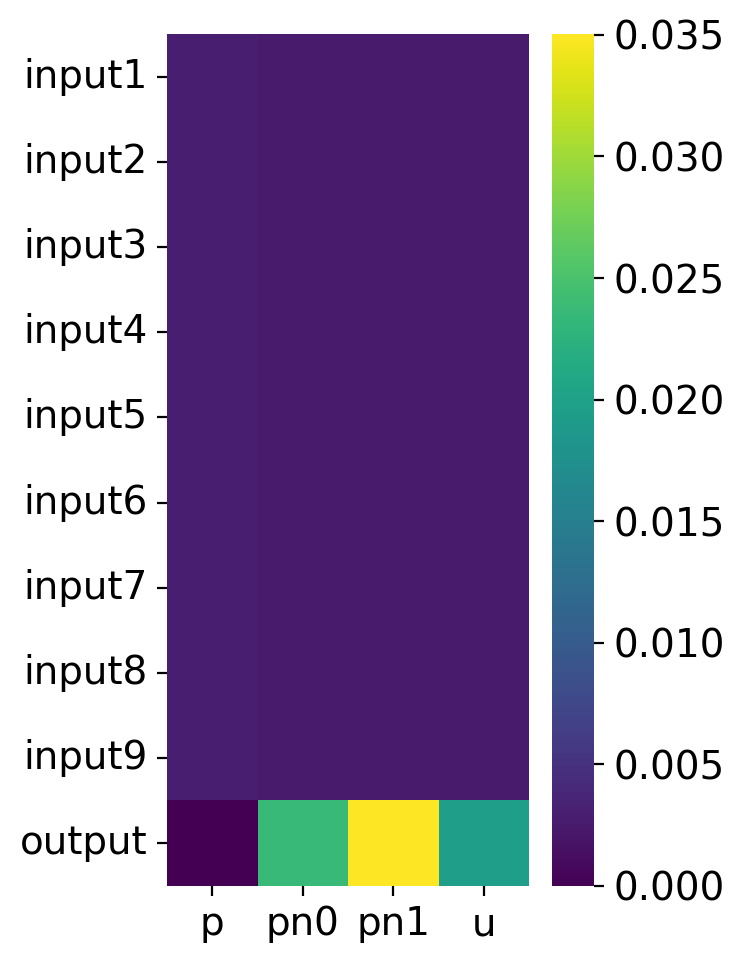

In [40]:
# derive the scores
fig, ax = plt.subplots(figsize=[2.9, 5.6])
ax = sns.heatmap(df_expr, cmap='viridis')
ax.grid(False)

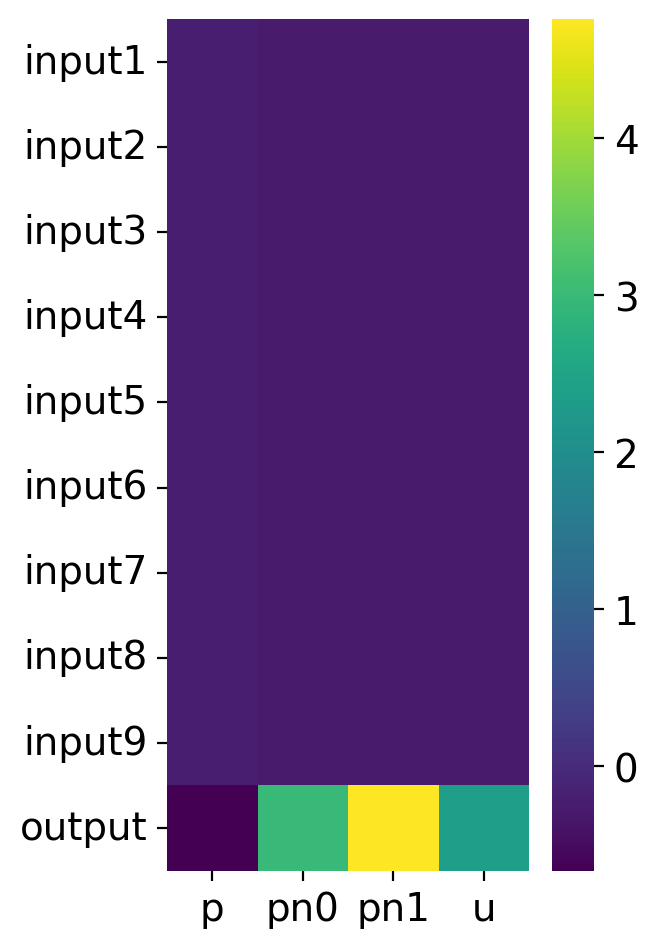

In [41]:
# derive the scores
df_expr -= np.mean(df_expr.values.flatten())
df_expr /= np.std(df_expr.values.flatten())
fig, ax = plt.subplots(figsize=[2.9, 5.6])
ax = sns.heatmap(df_expr, cmap='viridis')
ax.grid(False)

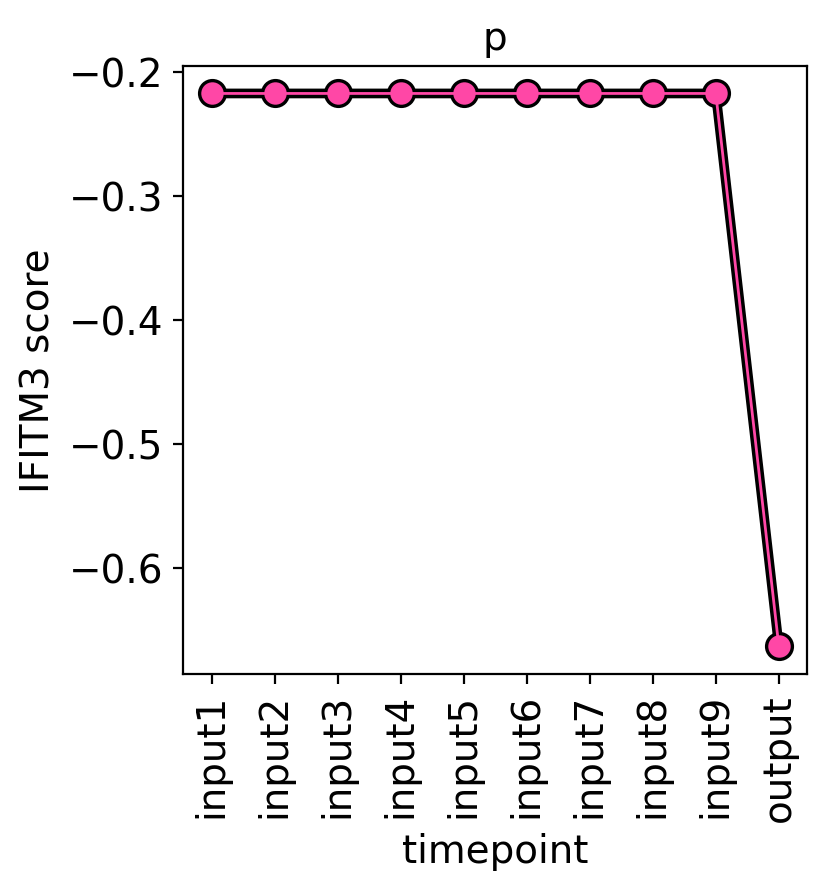

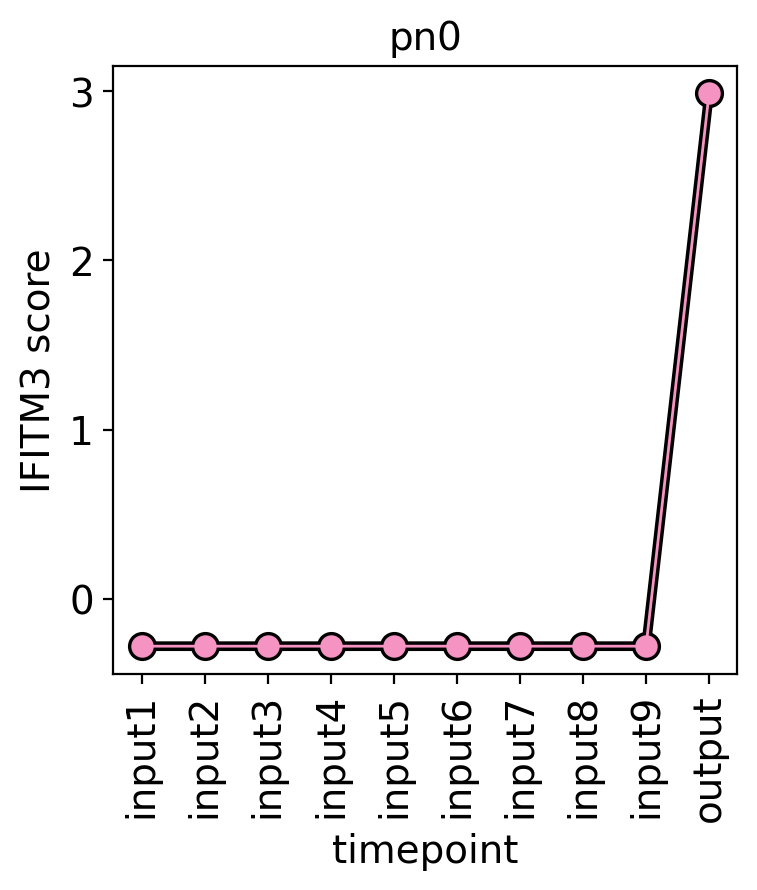

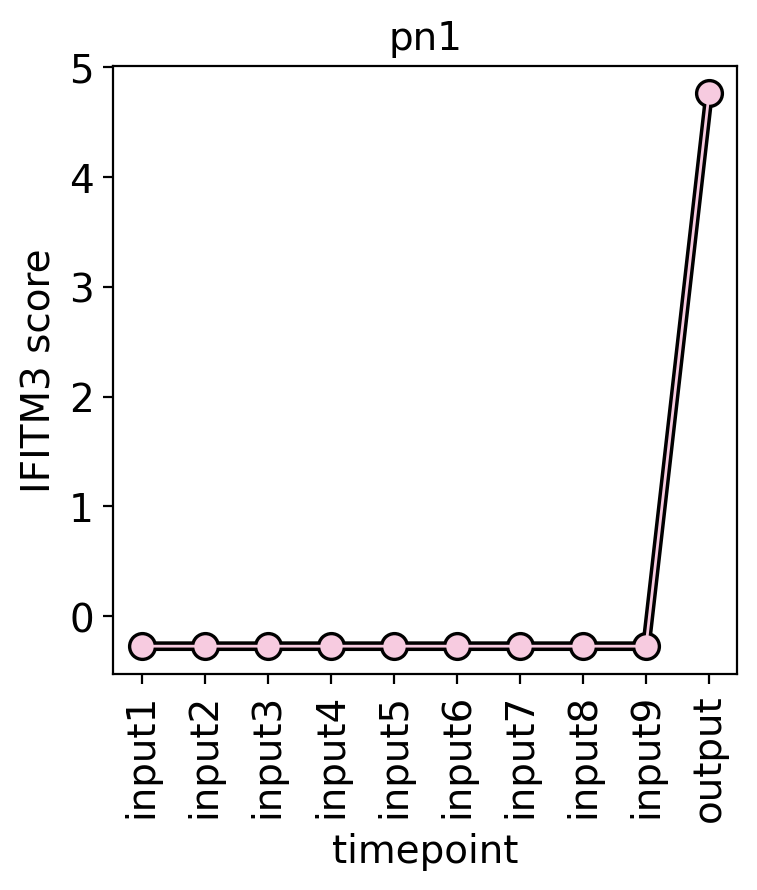

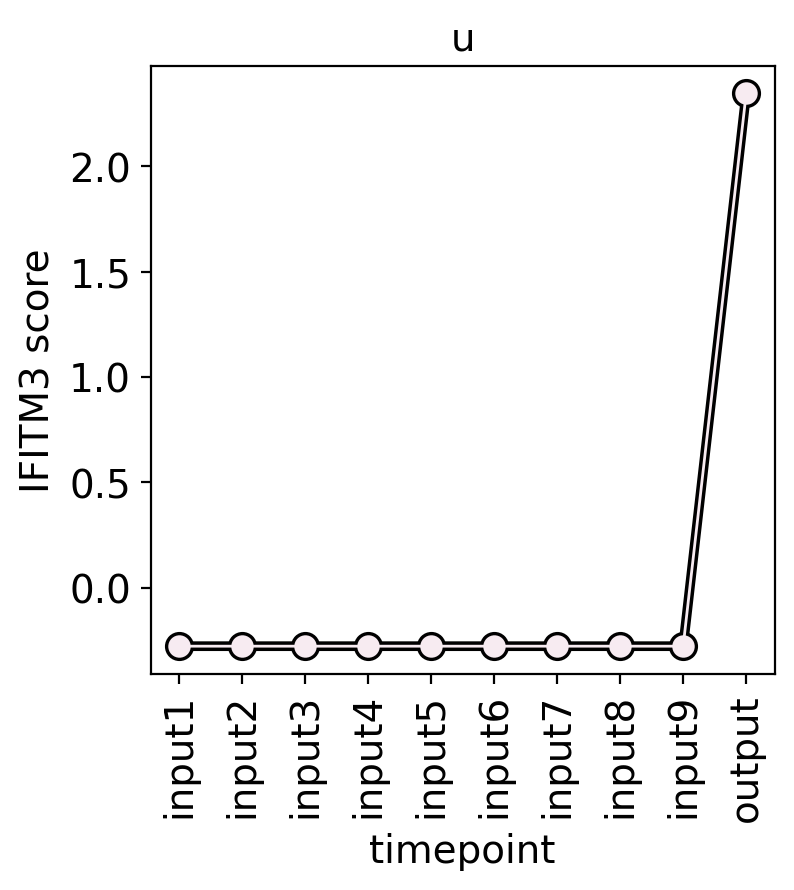

In [42]:
# derive the scores
for col, color in zip(['p','pn0','pn1','u'], ['#ff47a6','#f593c2','#f7cbe0','#f7ebf1']):
    fig, ax = plt.subplots(figsize=[4, 4])
    ax.scatter(df_expr.index, df_expr[col], color='k', s=9e1, zorder=1)
    ax.scatter(df_expr.index, df_expr[col], color=color, s=5e1, zorder=2)
    ax.plot(df_expr.index, df_expr[col], color='k', lw=3.5, zorder=0)
    ax.plot(df_expr.index, df_expr[col], color=color, lw=1, zorder=2)
    ax.grid(False)
    ax.tick_params(axis='x', labelrotation=90)
    ax.set(xlabel='timepoint', ylabel='IFITM3 score', title=col)